In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
data = pd.read_csv("21-california_housing_prices.csv")

| **Column Name**   | **Description** |
|-------------------|-------------|
| **longitude**     | A measure of how far west a house is; a higher value is farther west |
| **latitude**      | A measure of how far north a house is; a higher value is farther north |
| **housingMedianAge** | Median age of a house within a block; a lower number is a newer building |
| **totalRooms**    | Total number of rooms within a block |
| **totalBedrooms** | Total number of bedrooms within a block |
| **population**    | Total number of people residing within a block |
| **households**    | Total number of households, a group of people residing within a home unit, for a block |
| **medianIncome**  | Median income for households within a block of houses (measured in tens of thousands of US Dollars) |
| **medianHouseValue** | Median house value for households within a block (measured in US Dollars) |
| **oceanProximity** | Location of the house with respect to ocean/sea |


In [76]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [78]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [79]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

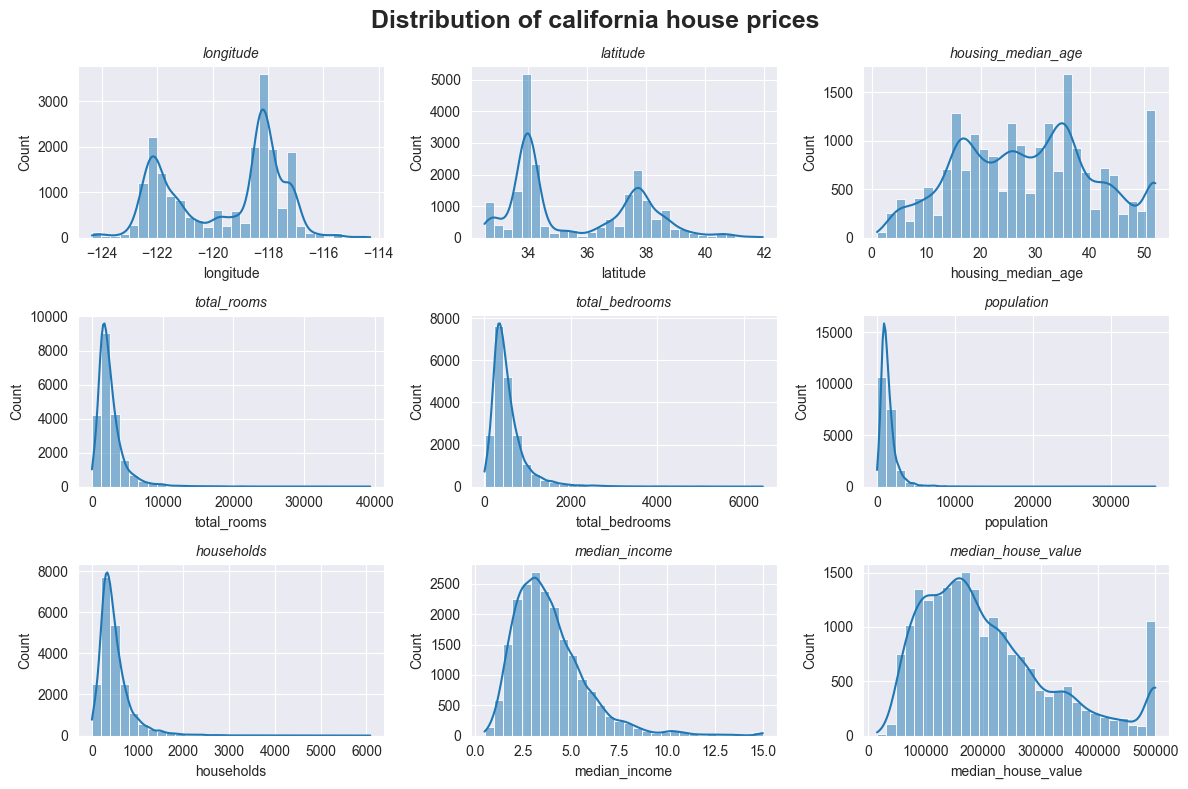

In [80]:
float_columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
fig.suptitle("Distribution of california house prices", fontsize=18, fontweight="bold")

for i,col in enumerate(float_columns):
    row = i // 3
    col_index = i % 3
    ax = axes[row, col_index]
    sns.histplot(data = data, x = col, kde = True, ax = ax, bins = 30)
    ax.set_title(col, fontsize = 10, fontstyle="italic")

plt.tight_layout()
plt.show()

In [81]:
data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


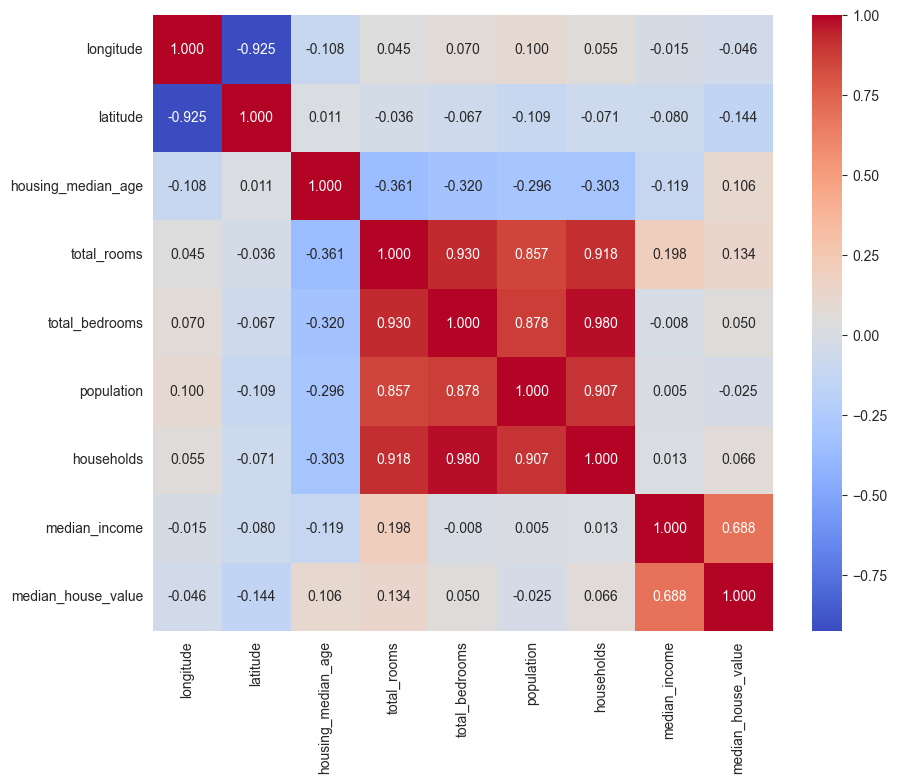

In [82]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".3f")
plt.show()

In [83]:
def detect_outliers(data, threshold = 1.5):
    outliers_summary = {}

    numeric_columns = data.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = data[ (data[col] < lower_bound) | (data[col] > upper_bound)]

        outliers_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outlier_percentage": outliers.shape[0] / data.shape[0] * 100,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        }
    return pd.DataFrame(outliers_summary)

In [84]:
detect_outliers(data, threshold = 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outlier_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [85]:
def remove_outliers(data, target_column, threshold = 1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

In [86]:
def remove_outliers_all(data, threshold = 1.5):
    data_clean = data.copy()

    numeric_columns = data.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]
    return data_clean.copy()

In [87]:
print("Original data shape:", data.shape)

data_target_clean = remove_outliers(data, "median_house_value")
print("Only target column shape:", data_target_clean.shape)

data_all_clean = remove_outliers_all(data)
print("All columns shape:", data_all_clean.shape)

Original data shape: (20640, 10)
Only target column shape: (19569, 10)
All columns shape: (17446, 10)


In [88]:
data_target_clean.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [89]:
data_target_clean[data_target_clean["total_bedrooms"].isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [90]:
data_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19369.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,539.893335,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,422.650225,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,648.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [91]:
data_target_clean["total_bedrooms"] = data_target_clean["total_bedrooms"].fillna(data_target_clean["total_bedrooms"].median())

C:\Users\Muham\AppData\Local\Temp\ipykernel_11604\2759960952.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_target_clean["total_bedrooms"] = data_target_clean["total_bedrooms"].fillna(data_target_clean["total_bedrooms"].median())


In [92]:
data_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,538.841739,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,420.612109,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,299.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,645.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [93]:
data_target_clean.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [94]:
#onehot encoding
data_target_clean["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64

In [95]:
data_target_clean = pd.get_dummies(data_target_clean, columns=["ocean_proximity"], drop_first = True)

In [96]:
data_target_clean

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [97]:
X = data_target_clean.drop("median_house_value", axis = 1)
y = data_target_clean["median_house_value"]

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 15)

In [100]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [101]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [102]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))

    return mae, rmse, r2

In [103]:
models = {
    "Linear Regression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(),
    "KNeighborsRegressor" : KNeighborsRegressor(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
    "RandomForestRegressor" : RandomForestRegressor(),
    "AdaBoostRegressor" : AdaBoostRegressor(),
    "GradientBoostingRegressor" : GradientBoostingRegressor(),
    "XGBRegressor" : XGBRegressor(),
}

In [104]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Training Set")
    print("Root Mean Squared Error (RMSE): ", model_train_rmse)
    print("Mean Absolute Error: ", model_train_mae)
    print("R2 Score: ", model_train_r2)

    print("---------------------")

    print("Model performance for Test Set")
    print("Root Mean Squared Error (RMSE): ", model_test_rmse)
    print("Mean Absolute Error: ", model_test_mae)
    print("R2 Score: ", model_test_r2)

    print("---------------------")
    print("\n")

Linear Regression
Model performance for Training Set
Root Mean Squared Error (RMSE):  59377.105929262376
Mean Absolute Error:  43858.38748241092
R2 Score:  0.6104236470924751
---------------------
Model performance for Test Set
Root Mean Squared Error (RMSE):  58769.54725739207
Mean Absolute Error:  43594.36386300802
R2 Score:  0.6263296157229532
---------------------


Ridge
Model performance for Training Set
Root Mean Squared Error (RMSE):  59381.168680071445
Mean Absolute Error:  43864.6773149373
R2 Score:  0.6103703334199277
---------------------
Model performance for Test Set
Root Mean Squared Error (RMSE):  58763.961258060284
Mean Absolute Error:  43597.1429124486
R2 Score:  0.6264006465004597
---------------------


Lasso
Model performance for Training Set
Root Mean Squared Error (RMSE):  59377.14466856272
Mean Absolute Error:  43859.008585346455
R2 Score:  0.6104231387510856
---------------------
Model performance for Test Set
Root Mean Squared Error (RMSE):  58768.46230442247


In [70]:
xgboost_params = {
    "learning_rate": [0.1, 0.01],
    "max_depth": [5, 8, 12, 20],
    "n_estimators": [100, 200, 300],
    "colsample_bytree": [0.3, 0.4, 0.5, 0.7, 1]
}

In [71]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [72]:
rscv = RandomizedSearchCV(estimator = XGBRegressor(), param_distributions = xgboost_params, cv=5, n_jobs=-1)

In [ ]:
rscv.fit(X_train, y_train)

In [36]:
rscv.best_params_

{'n_estimators': 300,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.4}

In [105]:
model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, colsample_bytree=1)

In [106]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [107]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

print(list(models.keys())[i])
print("Model performance for Training Set")
print("Root Mean Squared Error (RMSE): ", model_train_rmse)
print("Mean Absolute Error: ", model_train_mae)
print("R2 Score: ", model_train_r2)

print("---------------------")

print("Model performance for Test Set")
print("Root Mean Squared Error (RMSE): ", model_test_rmse)
print("Mean Absolute Error: ", model_test_mae)
print("R2 Score: ", model_test_r2)

print("---------------------")
print("\n")

XGBRegressor
Model performance for Training Set
Root Mean Squared Error (RMSE):  30283.613867573178
Mean Absolute Error:  21324.11134238347
R2 Score:  0.898662558437413
---------------------
Model performance for Test Set
Root Mean Squared Error (RMSE):  41509.52590261606
Mean Absolute Error:  28360.088510062702
R2 Score:  0.8135855667461909
---------------------




In [152]:
data_target_clean

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [153]:
from scipy.stats import skew

In [154]:
data_target_clean.apply(skew).sort_values(ascending=False)

ocean_proximity_ISLAND        62.536391
population                     4.961787
total_rooms                    4.228578
total_bedrooms                 3.479223
households                     3.406650
ocean_proximity_NEAR BAY       2.560066
ocean_proximity_NEAR OCEAN     2.287085
median_income                  0.889306
median_house_value             0.755894
ocean_proximity_INLAND         0.708083
latitude                       0.455656
housing_median_age             0.070466
longitude                     -0.289687
dtype: float64

In [155]:
import math

def all_hist(data, title_pre = ""):
    num_cols = data.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(4*n_rows, 5*n_cols))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f"{title_pre} {col}")
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

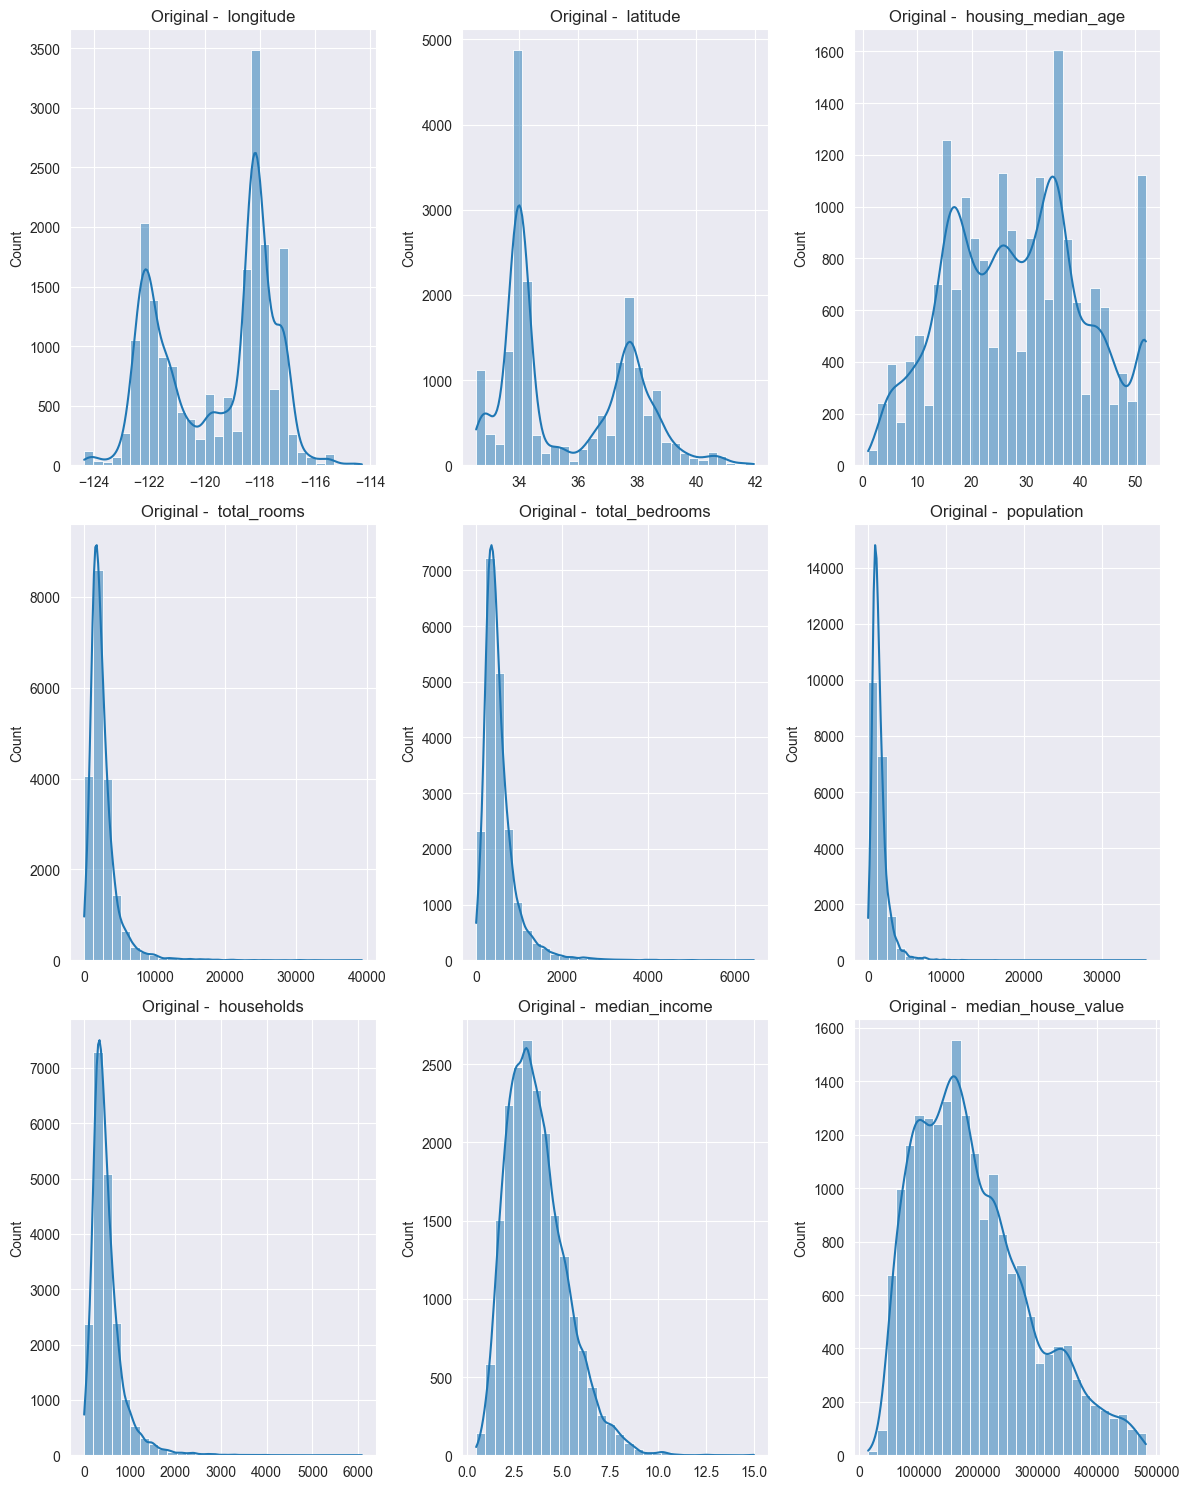

In [156]:
all_hist(data_target_clean, title_pre="Original - ")

In [157]:
numeric_features = [
    'longitude', 'latitude', 'housing_median_age',
    'total_rooms', 'total_bedrooms', 'population',
    'households', 'median_income'
]

dummy_features = [col for col in X_train.columns if col not in numeric_features]


In [158]:
dummy_features

['ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

In [159]:
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(method="yeo-johnson"), numeric_features),
        ("cat", "passthrough", dummy_features)
    ]
)

In [160]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [161]:
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

In [162]:
X_train_transformed_df

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
6487,7.771561e-16,-0.670997,0.486589,0.050535,0.024399,0.358262,0.058133,-0.018646,1.0,0.0,0.0,0.0
15385,1.387779e-15,-1.204084,-0.970340,0.432472,0.522800,0.628352,0.363502,-0.940026,0.0,0.0,0.0,0.0
12111,1.165734e-15,-0.721609,0.022996,0.305957,0.685602,0.800713,0.621156,-0.907275,1.0,0.0,0.0,0.0
10811,8.326673e-16,-0.972150,-0.296774,0.225063,0.655914,0.434484,0.557085,-0.254036,0.0,0.0,0.0,0.0
3290,-1.471046e-15,1.423073,-0.056065,-0.548070,-0.448934,-0.944478,-0.697868,-2.133232,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6857,6.938894e-16,-0.696213,-0.056065,-0.355082,-0.693242,-0.593331,-0.599422,1.324302,0.0,0.0,0.0,0.0
17117,-1.276756e-15,0.937396,0.637451,0.043574,0.083895,0.721670,0.110812,-0.815634,0.0,0.0,1.0,0.0
2726,2.275957e-15,-1.599086,0.179499,-1.336357,-1.128894,-0.681751,-1.090558,-1.525335,1.0,0.0,0.0,0.0
8422,5.828671e-16,-0.779416,0.256983,0.340278,0.660509,0.741306,0.522974,0.058431,0.0,0.0,0.0,0.0


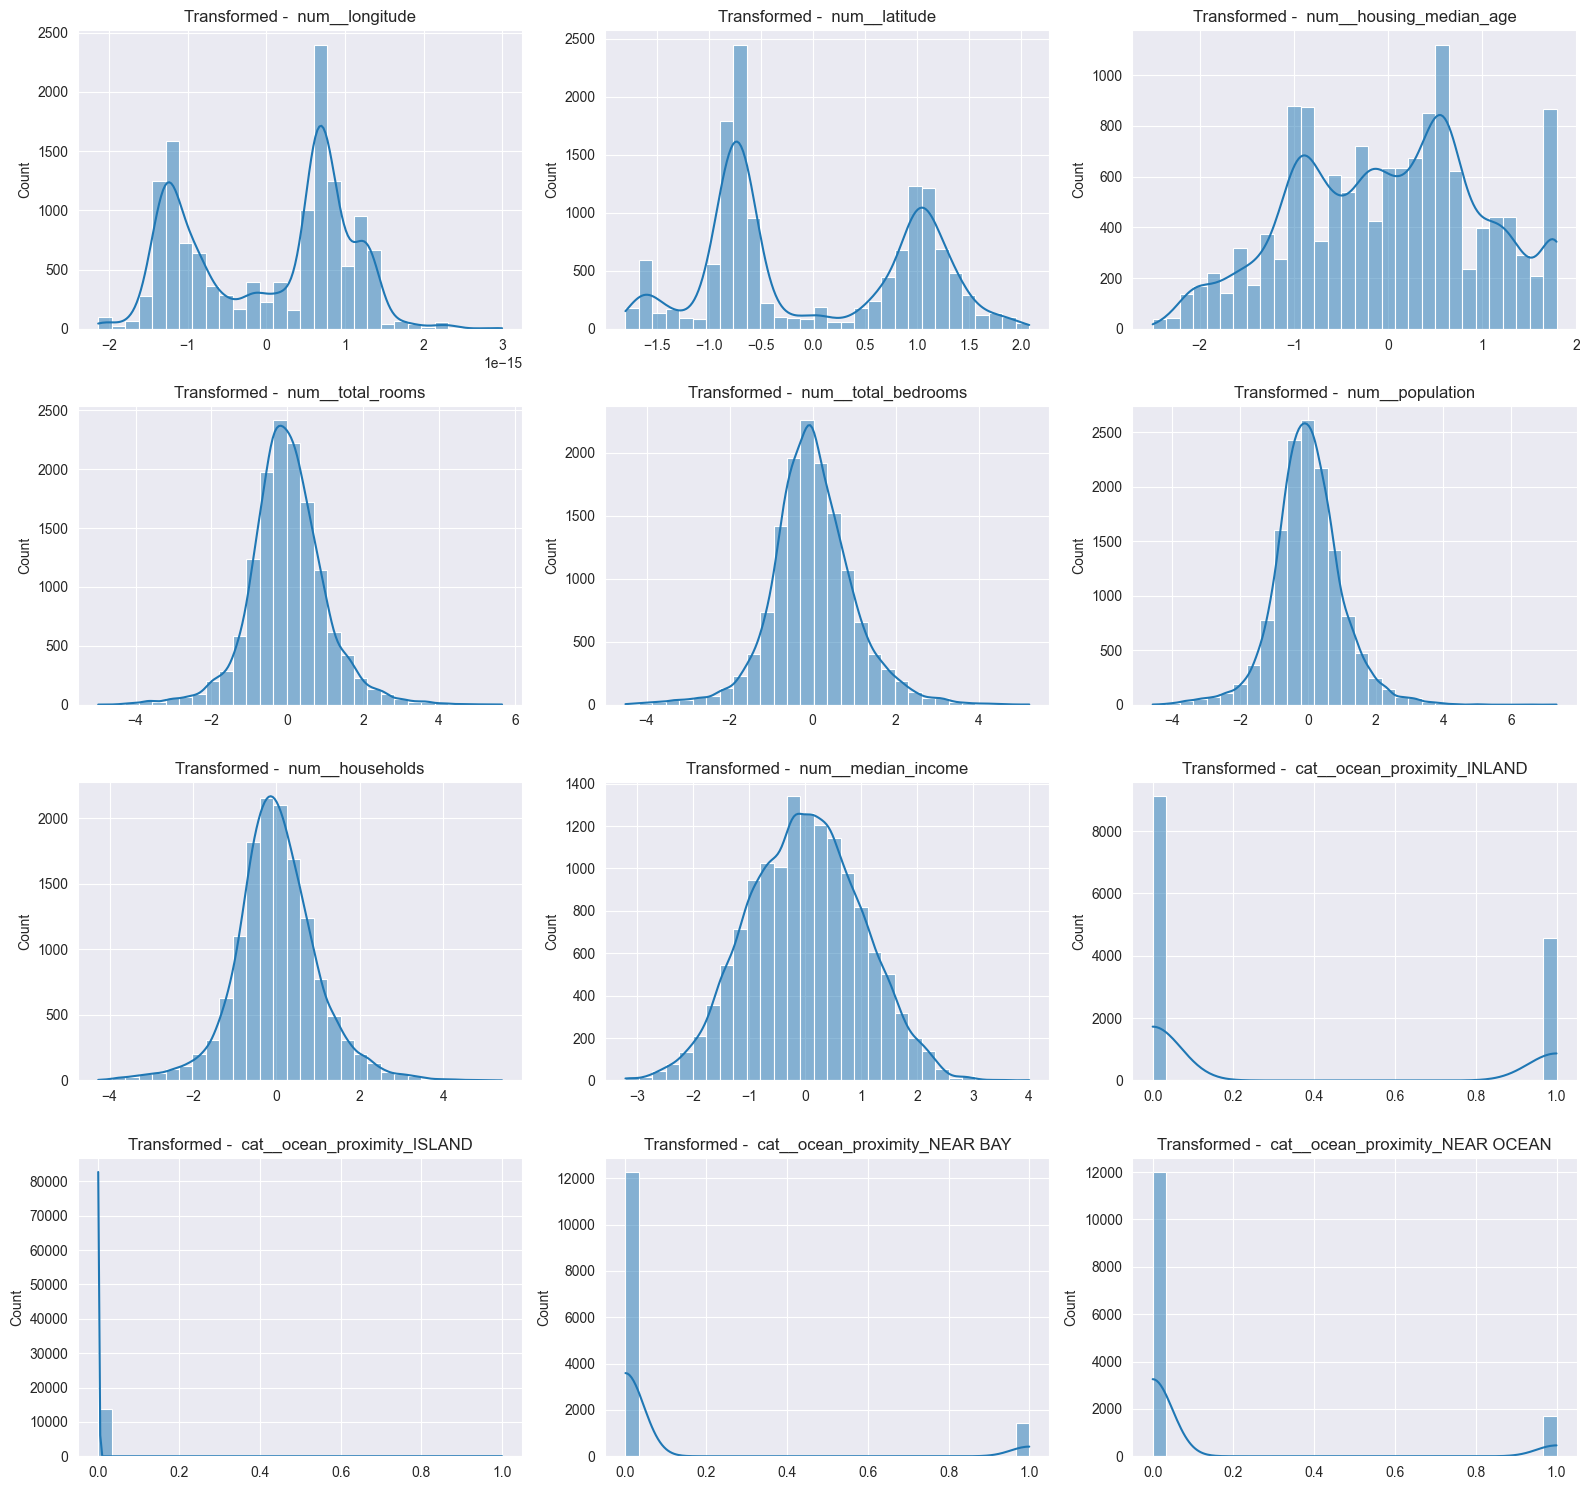

In [163]:
all_hist(X_train_transformed_df, title_pre="Transformed - ")

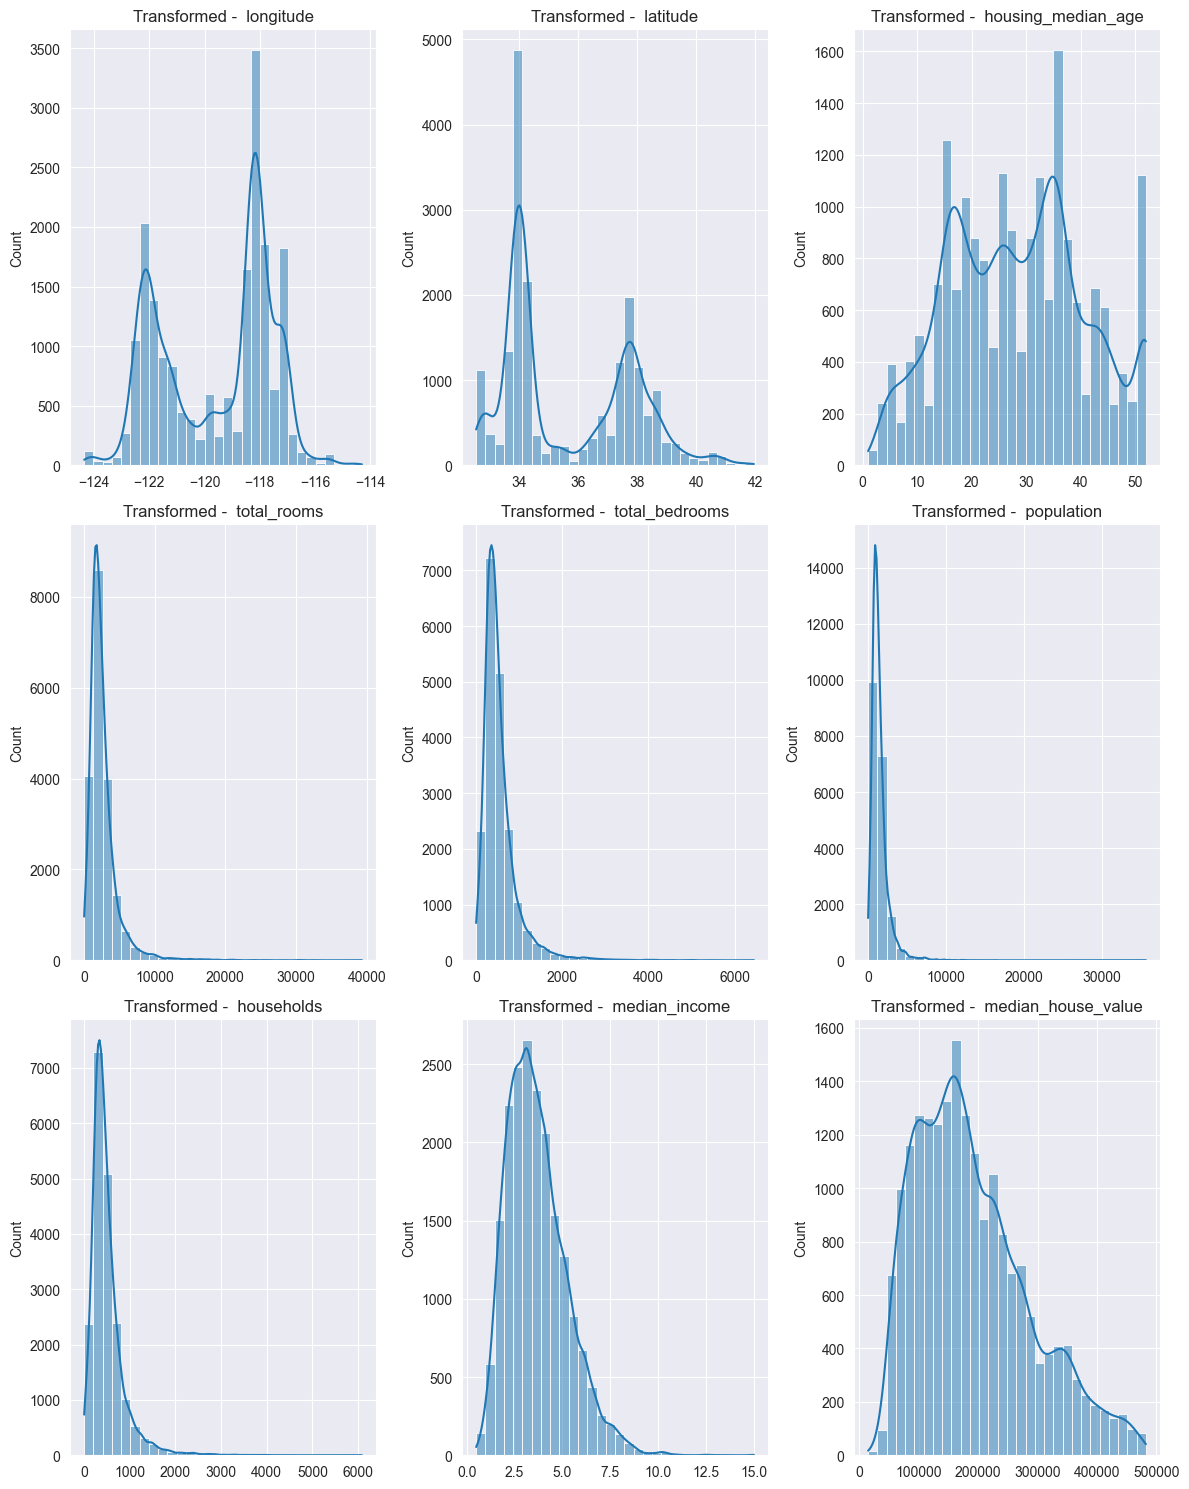

In [164]:
all_hist(data_target_clean, title_pre="Transformed - ")

In [180]:
from scipy.stats import boxcox

In [181]:
y_train_transformed, lambda_y = boxcox(y_train)

In [182]:
def inverse_boxcox(y, lambda_):
    if lambda_ ==0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [189]:
from xgboost import XGBRegressor

In [291]:
model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, colsample_bytree=1)
model.fit(X_train_transformed, y_train_transformed)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [292]:
y_pred_transformed = model.predict(X_test_transformed)

In [293]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [294]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [295]:
print("Model performance for Test Set")
print("R2 Score: ", r2_score(y_test, y_pred_original))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred_original))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred_original))

Model performance for Test Set
R2 Score:  0.8035572986078892
Mean Squared Error:  1815732675.8226664
Mean Absolute Error:  28354.14342047214


In [296]:
y_train_pred_transformed = model.predict(X_train_transformed)
y_train_pred_original = inverse_boxcox(y_train_pred_transformed, lambda_y)
print("Model performance for Training Set")
print("R2 Score: ", r2_score(y_train, y_train_pred_original))
print("Mean Squared Error: ", mean_squared_error(y_train, y_train_pred_original))
print("Mean Absolute Error: ", mean_absolute_error(y_train, y_train_pred_original))

Model performance for Training Set
R2 Score:  0.8861114651011642
Mean Squared Error:  1030683848.9502454
Mean Absolute Error:  21905.92017288525
